# Spam detection model comparison

Practical assignment for the **Machine Learning** course. This project addresses a
supervised spam email classification problem.

## Dataset

The project uses the [Email Spam Classification Dataset](https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv), available on Kaggle.

## Project Overview

### T1 - Problem Characterization and Spot-Checking

In the first stage, a Python pipeline loads and preprocesses the data, performs
exploratory data analysis, and quickly compares different supervised learning
algorithms. The results are evaluated using appropriate metrics, summarized, and
visualized to identify the most promising models.

The expected outputs are a reproducible Python pipeline, a technical report
describing the problem, methodology, and spot-checking results, and a selection of
2-3 algorithms for further investigation.

### T2 - In-Depth Evaluation

In the second stage, the selected models will be improved through hyperparameter
optimization, more robust evaluation, and statistical analysis. The best model will
also be interpreted to understand its quantitative results and extract insights
about email classification.

The final outputs will be an updated pipeline, a complete report, and an oral
presentation of the project.

# 1. Data downloading

In [1]:
%pip install -q kagglehub

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("balaka18/email-spam-classification-dataset-csv", output_dir="data")

print("Path to dataset files:", path)

100%|██████████| 1.66M/1.66M [00:00<00:00, 1.93MB/s]

Extracting files...


Path to dataset files: data


In [8]:
import pandas as pd

df = pd.read_csv('data/emails.csv')

print(df)

       Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  \
0        Email 1    0   0    1    0    0   0    2    0    0  ...         0   
1        Email 2    8  13   24    6    6   2  102    1   27  ...         0   
2        Email 3    0   0    1    0    0   0    8    0    0  ...         0   
3        Email 4    0   5   22    0    5   1   51    2   10  ...         0   
4        Email 5    7   6   17    1    5   2   57    0    9  ...         0   
...          ...  ...  ..  ...  ...  ...  ..  ...  ...  ...  ...       ...   
5167  Email 5168    2   2    2    3    0   0   32    0    0  ...         0   
5168  Email 5169   35  27   11    2    6   5  151    4    3  ...         0   
5169  Email 5170    0   0    1    1    0   0   11    0    0  ...         0   
5170  Email 5171    2   7    1    0    2   1   28    2    0  ...         0   
5171  Email 5172   22  24    5    1    6   5  148    8    2  ...         0   

      jay  valued  lay  infrastructure  military  allowing  ff 

## 1.1 Data summary

In [ ]:
print(f"Rows: {df.shape[0]}")
print(f"Collumns: {df.shape[1]}\n")

print("Data types:")
print(df.dtypes.value_counts())

print("\nMissing values:")
print(df.isna().sum().sum())

#print("\nClass distribution:")
#print(df["Prediction"].value_counts())
#print(df["Prediction"].value_counts(normalize=True).mul(100).round(2))

Rows: 5172
Collumns: 3002

Data types:
int64    3001
str         1
Name: count, dtype: int64

Missing values:
0

Class distribution:
Prediction
0    3672
1    1500
Name: count, dtype: int64
Prediction
0    71.0
1    29.0
Name: proportion, dtype: float64


In [17]:
import matplotlib.pyplot as plt

def plot_class_distribution(df: pd.array, target: str, classes: list):
  class_counts = df[target].value_counts().sort_index()
  class_labels = {0: classes[0], 1: classes[1]}
  labels = [class_labels.get(value, str(value)) for value in class_counts.index]

  fig, ax = plt.subplots(figsize=(7, 5))
  bars = ax.bar(labels, class_counts.values, color=["#4C78A8", "#F58518"])
  ax.set_title("Class distribution")
  ax.set_xlabel("Class")
  ax.set_ylabel("Quantity")
  ax.bar_label(bars, labels=[f"{count} ({count / class_counts.sum():.1%})" for count in class_counts])
  ax.set_ylim(0, class_counts.max() * 1.15)
  plt.tight_layout()
  plt.show()

def plot_feature_frequency(df: pd.DataFrame, features: list[str], n: int):
  if not isinstance(n, int) or n == 0:
    raise ValueError("n must be an integer different from zero")
  if isinstance(features, str) or len(features) == 0:
    raise ValueError("features must contain at least one column name")

  missing_features = [feature for feature in features if feature not in df.columns]
  if missing_features:
    raise ValueError(f"Features not found in df: {missing_features}")

  feature_counts = df.loc[:, list(features)].sum().sort_values(ascending=False)
  non_zero_counts = feature_counts[feature_counts > 0]
  selected = (
    non_zero_counts.nlargest(n) if n > 0
    else non_zero_counts.nsmallest(abs(n))
  ).sort_values(ascending=True)

  fig_height = max(5, len(selected) * 0.32)
  fig, ax = plt.subplots(figsize=(10, fig_height))
  bars = ax.barh(selected.index, selected.values, color="#54A24B")
  ranking = "most frequent" if n > 0 else "least frequent"
  ax.set_title(f"{abs(n)} {ranking} features")
  ax.set_xlabel("Total number of occurrences")
  ax.set_ylabel("Feature")
  ax.bar_label(bars, padding=3)
  ax.set_xlim(0, selected.max() * 1.12)
  plt.tight_layout()
  plt.show()
  return selected

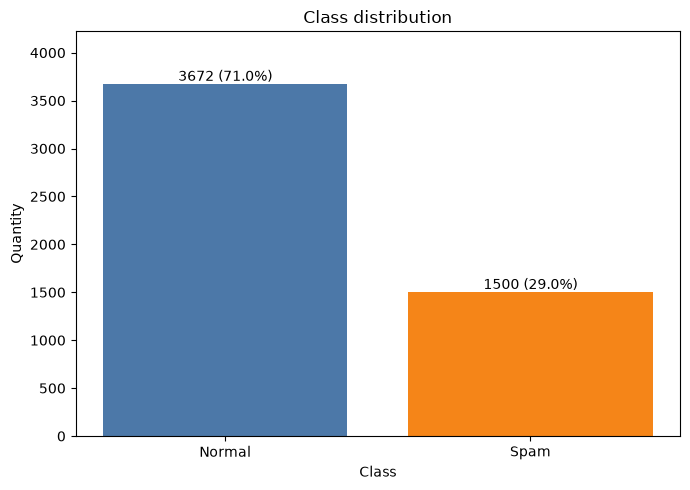

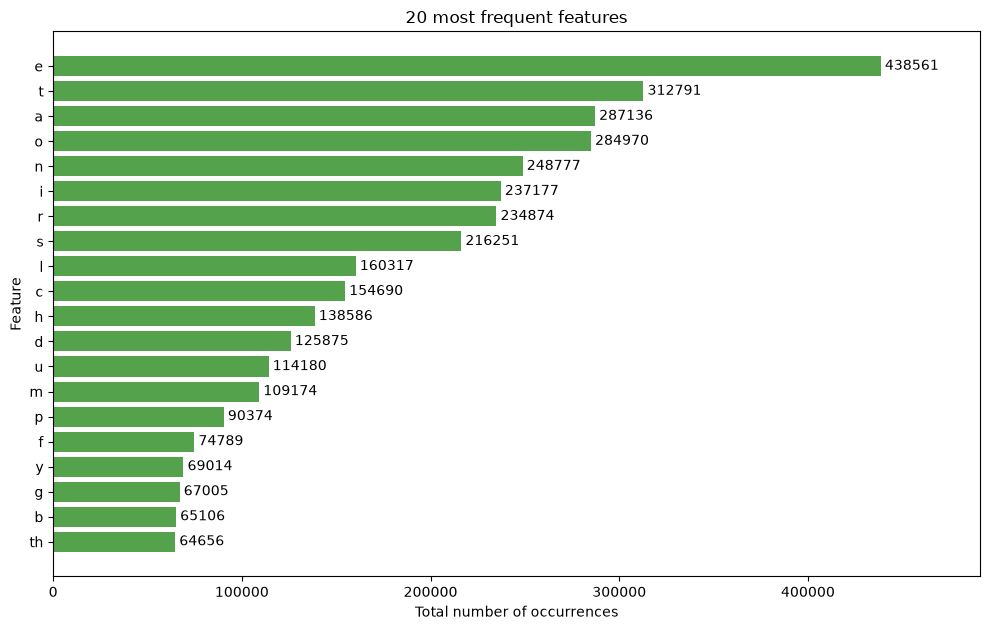

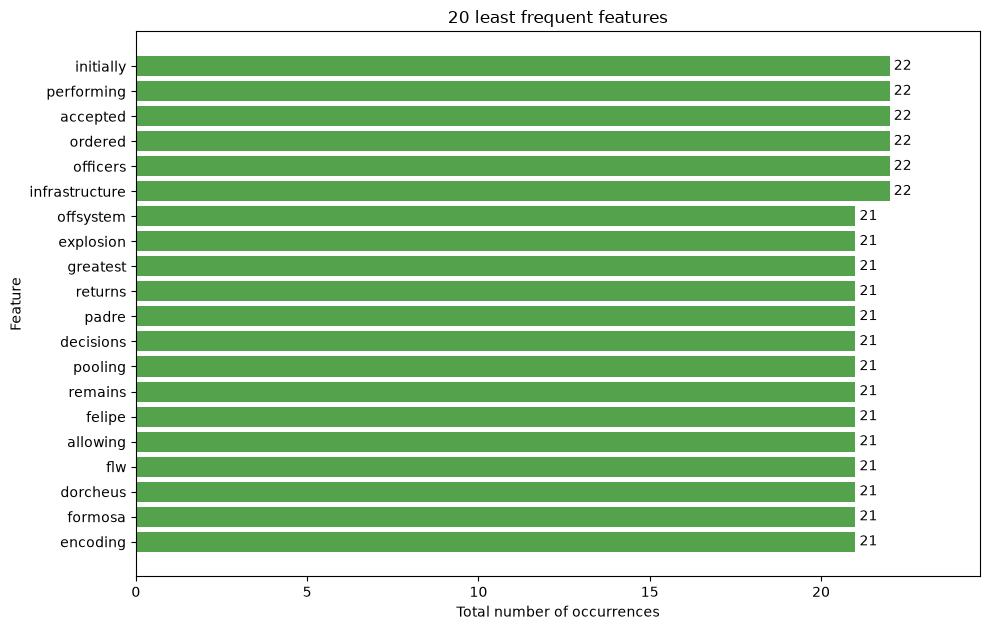

In [19]:
plot_class_distribution(df, 'Prediction', ['Normal', 'Spam'])

top_n = [20, -20]
features = features = df.columns.difference(["Email No.", "Prediction"]).tolist()

for n in top_n:
  plot_feature_frequency(df, features, n);